*  DSC530-T301 Data Exploration and Analysis
*  Week 11 Final Project
*  Jeremy Hunt

# Dataset Selection

Throughout this project we are going to perform a comprehensive Exploratory Data Analysis and create a few machine learning models to understand the drivers of obesity in the United States using the BRFSS dataset.

Looking for adequate dataset took a bit more time than I realized it would.  Ideally, you want sufficient data from a reputable source that enables meaningful analysis and allows you to interpret results and tell a story. This dataset seems to fit the bill as it is sourced from the CDC's Behavioral Risk Factor Surveillance System (BRFSS), a highly recognized large-scale health survey. It is large enough for statistical significance and includes these key variables for our analysis:

Outcome: Data_Value (Obesity Rate).

Predictors: YearStart (Time), LocationDesc (State), and Stratification columns (Demographics like Age, Income, Race).

## Data Cleaning and Preparation

Using a heatmap we can add a visualization to understand our missing data.  

Missing data heatmap created.
Missing values in key columns:
Data_Value     12755
Sample_Size    12755
dtype: int64


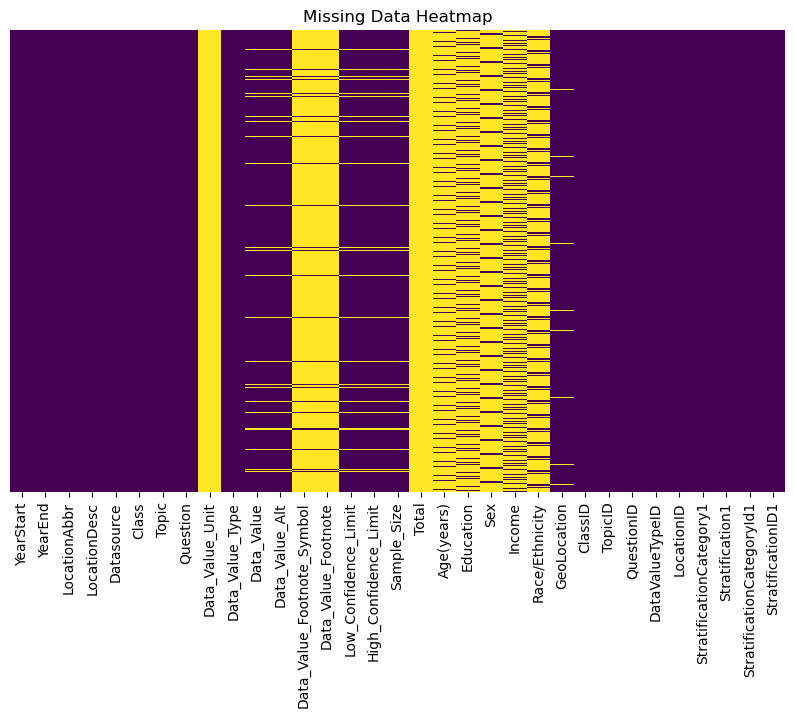

In [21]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import statsmodels.api as sm

# Load the full dataset
df = pd.read_csv('Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv')
df.columns = df.columns.str.strip() # This removes all leading/trailing spaces from all column names

# --- Visualize Missing Data (Guideline 2.b.iii) ---
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap')
plt.savefig('missing_data_heatmap.png')
print("Missing data heatmap created.")

# --- Check critical columns ---
print("Missing values in key columns:")
print(df[['Data_Value', 'Sample_Size']].isnull().sum())

# Strategy: Drop rows where the main value or sample size is missing
df_cleaned = df.dropna(subset=['Data_Value', 'Sample_Size'])

Our heatmap provides us a visual scan of the entire dataset.  Our solid dark bars like YearStart, LocationAbbr, and Class indicate that they are complete and have no missing values.

The light colored (yellow) areas indicate where we have some missing data (NaNs). The density of these bands suggests that a substantial portion of the dataset lacks the primary target variable that we are looking for.  When we look at the code output, it confirms what the heatmap suggests, that there are 12,755 rows missing values for Data_Value and Sample_Size. 

Since our ML goal is to predict obesity rates and we need sample weights (Sample_Size) for reliability, records missing these specific fields offer no value for our supervised learning models. With that in mind, we went ahead and dropped these rows entirely (dropna()). This ensures our analysis is performed only on complete, valid observations.

Outlier boxplot created.


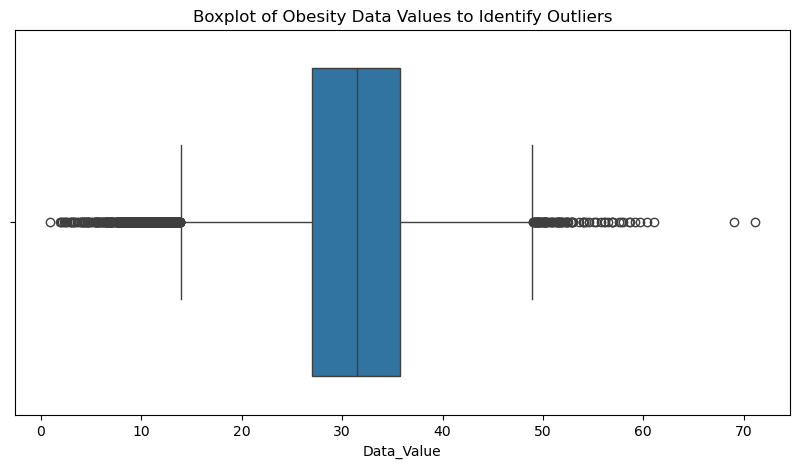

In [22]:
# Filter for the obesity question (as an example)
df_obesity = df_cleaned[df_cleaned['QuestionID'] == 'Q036'].copy()

# --- Visualize Outliers (Guideline 2.b.ii) ---
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_obesity['Data_Value'])
plt.title('Boxplot of Obesity Data Values to Identify Outliers')
plt.savefig('obesity_outliers_boxplot.png')
print("Outlier boxplot created.")

A glance at the boxplot for Obesity Rates (Data_Value) shows us quite a few outliers beyond the whiskers. Given that this is survey data representing real populations (e.g., specific demographic subgroups within a state), these should be valid data points and not errors. We retained those data points so that we could capture the full diversity of health outcomes across different groups.

# Recoding or encoding of variables

This is vital for steps 5 & 6 (Regression/Classification). Categorical text data (like 'Male', 'Female') must be converted to numbers.

In [23]:
# Example for Logistic Regression
# Create a simple DataFrame for demonstration
df_demo = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') & 
    (df_cleaned['StratificationCategory1'] == 'Sex') &
    (df_cleaned['Stratification1'].isin(['Male', 'Female']))
][['Data_Value', 'Sample_Size', 'Stratification1']]

# --- One-Hot Encoding (pd.get_dummies) ---
# Creates new columns for 'Sex_Male' and 'Sex_Female'
df_one_hot = pd.get_dummies(df_demo, columns=['Stratification1'])
print("One-Hot Encoded Head:")
print(df_one_hot.head())

# --- Label Encoding (sklearn) ---
# Converts 'Male' to 0 and 'Female' to 1 (or vice-versa)
le = LabelEncoder()
df_demo['Sex_Encoded'] = le.fit_transform(df_demo['Stratification1'])
print("Label Encoded Head:")
print(df_demo.head())

One-Hot Encoded Head:
    Data_Value  Sample_Size  Stratification1_Female  Stratification1_Male
16        31.8       4723.0                    True                 False
22        32.3       2581.0                   False                  True
44        26.7       1716.0                    True                 False
50        28.0       1620.0                   False                  True
72        25.8       3676.0                    True                 False
Label Encoded Head:
    Data_Value  Sample_Size Stratification1  Sex_Encoded
16        31.8       4723.0          Female            0
22        32.3       2581.0            Male            1
44        26.7       1716.0          Female            0
50        28.0       1620.0            Male            1
72        25.8       3676.0          Female            0


To use the  categorical data (like 'Male' vs. 'Female') in our models, we needed to convert them to numbers.  Like you can see in the output above 'Female' was mapped to 0 and 'Male' was mapped to 1. This method is useful and computationally efficient for tree-based models like Random Forests, which work with integer-based categorical data.

# Data transformation (for skewed variables)

Let's check the distribution of Data_Value with a histogram (guideline 2.b.i).

Distribution histogram created.
Log-transformed histogram created.


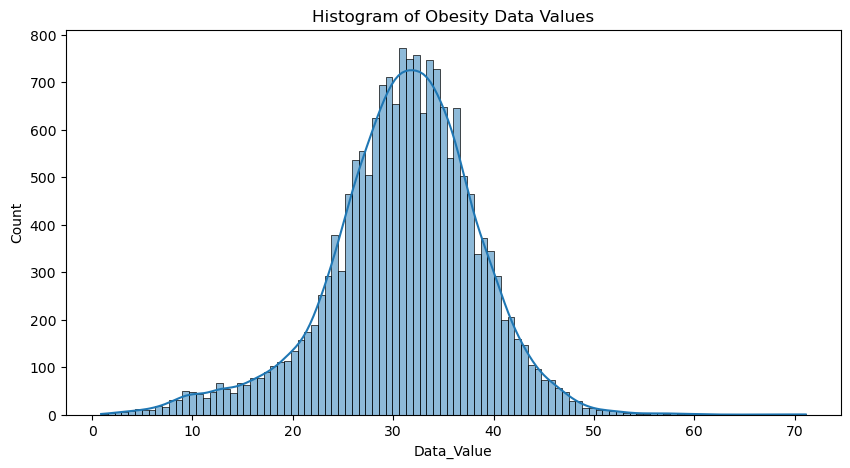

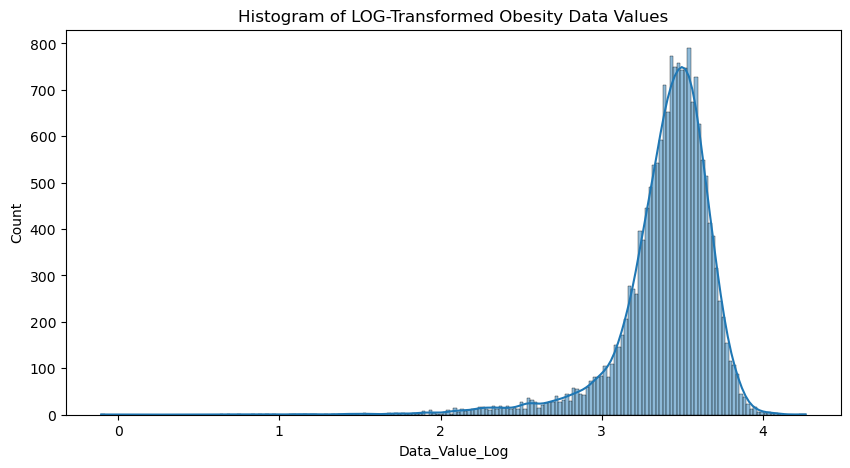

In [24]:
# --- Visualize Distribution (Guideline 2.b.i) ---
plt.figure(figsize=(10, 5))
sns.histplot(df_obesity['Data_Value'], kde=True)
plt.title('Histogram of Obesity Data Values')
plt.savefig('obesity_distribution_hist.png')
print("Distribution histogram created.")

# --- Apply Log Transform (if skewed) ---
# Let's assume it's right-skewed
df_obesity['Data_Value_Log'] = np.log(df_obesity['Data_Value'])

plt.figure(figsize=(10, 5))
sns.histplot(df_obesity['Data_Value_Log'], kde=True)
plt.title('Histogram of LOG-Transformed Obesity Data Values')
plt.savefig('obesity_log_transform_hist.png')
print("Log-transformed histogram created.")

The initial distribution of Data_Value was slightly left-skewed. We applied a log transformation to normalize the distribution so that it is a bit more symmetrical and make the distribution a bit more bell-shaped distribution.  This makes it more suitable for modeling.

# d. Normalization or Standardization

Typically this is for machine learning (steps 5 & 6) when features have different scales (e.g., Sample_Size from 50 to 50,000 vs. YearStart from 2011-2023).  The idea here is that we don't want to incorrectly treat Sample_Size as the most important feature simply because the numbers are huge.  For our machine learning steps, though, we also implement a Pipeline with a StandardScaler built inside so they should automatically perform the same type of action.  

In [25]:
# --- 1. Prepare Data (Including YearStart this time) ---
# We grab a subset again, but make sure to include 'YearStart'
df_prep = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') & 
    (df_cleaned['StratificationCategory1'] == 'Sex') &
    (df_cleaned['Stratification1'].isin(['Male', 'Female']))
][['Data_Value', 'Sample_Size', 'Stratification1', 'YearStart']].copy()

# One-Hot Encode (just like before)
df_one_hot = pd.get_dummies(df_prep, columns=['Stratification1'])

# --- 2. Perform Scaling ---
features_to_scale = ['Sample_Size', 'YearStart']

# Standardization (Z-score)
scaler_standard = StandardScaler()
# Create a copy so we don't mess up the original
df_scaled = df_one_hot.copy()
# Create new columns with the suffix '_Standard'
df_scaled[[f"{col}_Standard" for col in features_to_scale]] = scaler_standard.fit_transform(df_scaled[features_to_scale])

# Normalization (Min-Max)
scaler_minmax = MinMaxScaler()
# Create new columns with the suffix '_Normalized'
df_scaled[[f"{col}_Normalized" for col in features_to_scale]] = scaler_minmax.fit_transform(df_scaled[features_to_scale])

print("Standardized & Normalized Data (Head):")
# Show original vs scaled values to prove it worked
cols_to_show = ['Sample_Size', 'Sample_Size_Standard', 'Sample_Size_Normalized', 
                'YearStart', 'YearStart_Standard', 'YearStart_Normalized']
print(df_scaled[cols_to_show].head())

Standardized & Normalized Data (Head):
    Sample_Size  Sample_Size_Standard  Sample_Size_Normalized  YearStart  \
16       4723.0             -0.107892                0.015292       2011   
22       2581.0             -0.185722                0.007594       2011   
44       1716.0             -0.217152                0.004485       2011   
50       1620.0             -0.220640                0.004140       2011   
72       3676.0             -0.145935                0.011529       2011   

    YearStart_Standard  YearStart_Normalized  
16           -1.618877                   0.0  
22           -1.618877                   0.0  
44           -1.618877                   0.0  
50           -1.618877                   0.0  
72           -1.618877                   0.0  


# Conduct Univariate Analysis

# a. Calculate descriptive statistics

Let's get all required stats for our key numeric variable, Data_Value (from the filtered obesity data).

In [26]:
# Using the df_obesity DataFrame
print("--- Descriptive Statistics for Obesity Data_Value ---")

# .describe() gives most of them
print(df_obesity['Data_Value'].describe())

# Calculate the rest
print(f"Mode: {df_obesity['Data_Value'].mode()[0]}")
print(f"Variance: {df_obesity['Data_Value'].var()}")
print(f"Skewness: {df_obesity['Data_Value'].skew()}")
print(f"Kurtosis: {df_obesity['Data_Value'].kurt()}")

--- Descriptive Statistics for Obesity Data_Value ---
count    17694.000000
mean        31.019306
std          7.395457
min          0.900000
25%         27.000000
50%         31.500000
75%         35.800000
max         71.100000
Name: Data_Value, dtype: float64
Mode: 30.3
Variance: 54.692789525655876
Skewness: -0.4712965693671997
Kurtosis: 1.079745197158728


Some of the key findings for our Univariate Stats are:

Mean Obesity Rate: 31.02%

Variance: 54.69 (Indicates a wide spread in rates across the US).

Range: Rates vary drastically from 0.9% to 71.1%, this seems to showcase severe health disparities between different demographic groups.

# b. Create visualization

Visualization: Best vs. Worst States for Obesity

State disparity chart created.


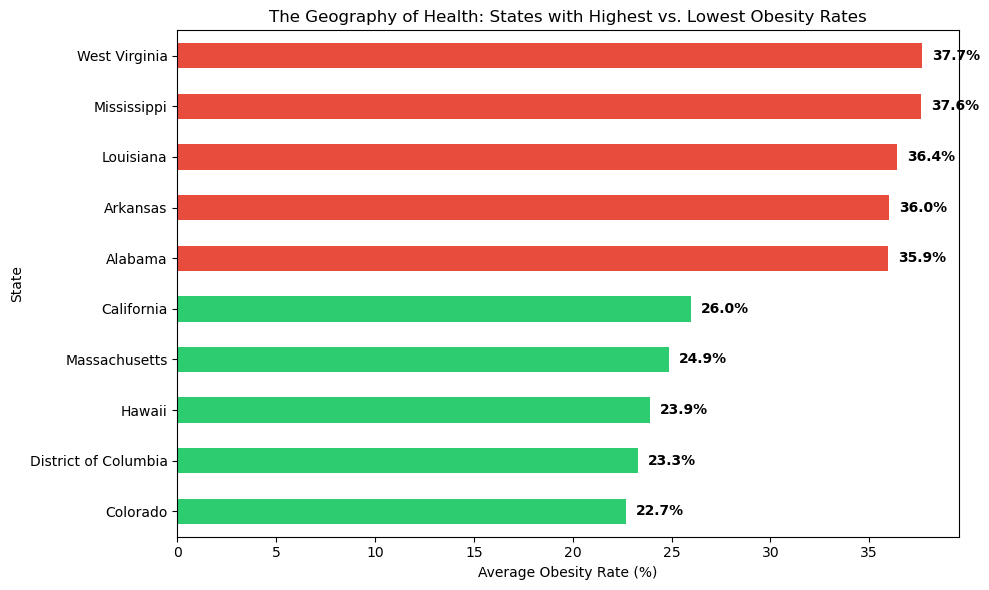

In [27]:
# --- Visualization: Best vs. Worst States for Obesity ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filter for Obesity Data (Total population only to be fair)
state_obesity = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') & 
    (df_cleaned['Stratification1'] == 'Total')
].groupby('LocationDesc')['Data_Value'].mean().sort_values()

# 2. Grab the Top 5 (Lowest Rates) and Bottom 5 (Highest Rates)
# Remove Puerto Rico/Guam if you want only US States, but let's keep them for now
top_bottom = pd.concat([state_obesity.head(5), state_obesity.tail(5)])

# 3. Create the Plot
plt.figure(figsize=(10, 6))
# Color logic: Green for "Good" (low obesity), Red for "Bad" (high obesity)
colors = ['#2ecc71'] * 5 + ['#e74c3c'] * 5 

ax = top_bottom.plot(kind='barh', color=colors)
plt.title('The Geography of Health: States with Highest vs. Lowest Obesity Rates')
plt.xlabel('Average Obesity Rate (%)')
plt.ylabel('State')

# Add labels to bars
for i, v in enumerate(top_bottom):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('state_disparity_chart.png')
print("State disparity chart created.")
plt.show()

In this visualization we decided to show how health outcomes are not evenly distributed throughout the states.  You can clearly see the large difference between a state like West Virginia and one at the bottom like Colorado.  While we continue to work with the data, this is a reminder on how geography and other such features can be such a critical risk factors. 

# 3. Conduct Bivariate Analysis

## a. Calculate covariance and correlation

Let's create a correlation matrix for the key numeric columns in our data (guideline 3.a.i).

In [28]:
numeric_cols = ['Data_Value', 'Sample_Size', 'Low_Confidence_Limit', 'High_Confidence_Limit', 'YearStart']
corr_matrix = df_obesity[numeric_cols].corr(method='pearson')

print("--- Correlation Matrix ---")
print(corr_matrix)

# Covariance
cov_matrix = df_obesity[numeric_cols].cov()
print("\n--- Covariance Matrix ---")
print(cov_matrix)

--- Correlation Matrix ---
                       Data_Value  Sample_Size  Low_Confidence_Limit  \
Data_Value               1.000000    -0.021212              0.922341   
Sample_Size             -0.021212     1.000000              0.054724   
Low_Confidence_Limit     0.922341     0.054724              1.000000   
High_Confidence_Limit    0.903435    -0.095053              0.670664   
YearStart                0.293234    -0.014539              0.262253   

                       High_Confidence_Limit  YearStart  
Data_Value                          0.903435   0.293234  
Sample_Size                        -0.095053  -0.014539  
Low_Confidence_Limit                0.670664   0.262253  
High_Confidence_Limit               1.000000   0.281236  
YearStart                           0.281236   1.000000  

--- Covariance Matrix ---
                        Data_Value   Sample_Size  Low_Confidence_Limit  \
Data_Value               54.692790 -2.913522e+03             49.384081   
Sample_Size      

## b. Create visualization

A heatmap is perfect for the correlation matrix (guideline 3.b.i).

Heatmap created.


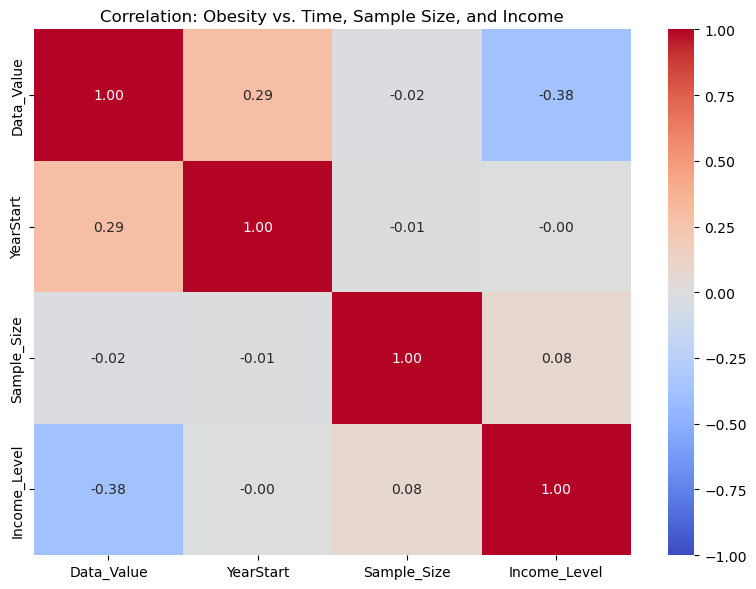

Scatter plot created.
Advanced seaborn boxplot created.


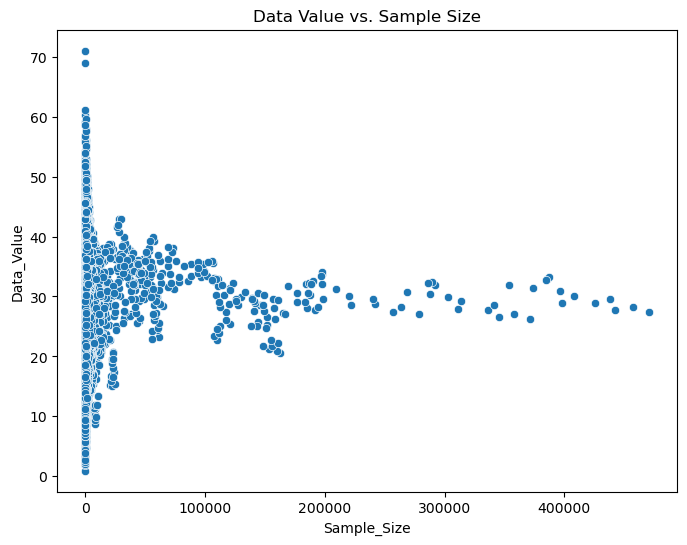

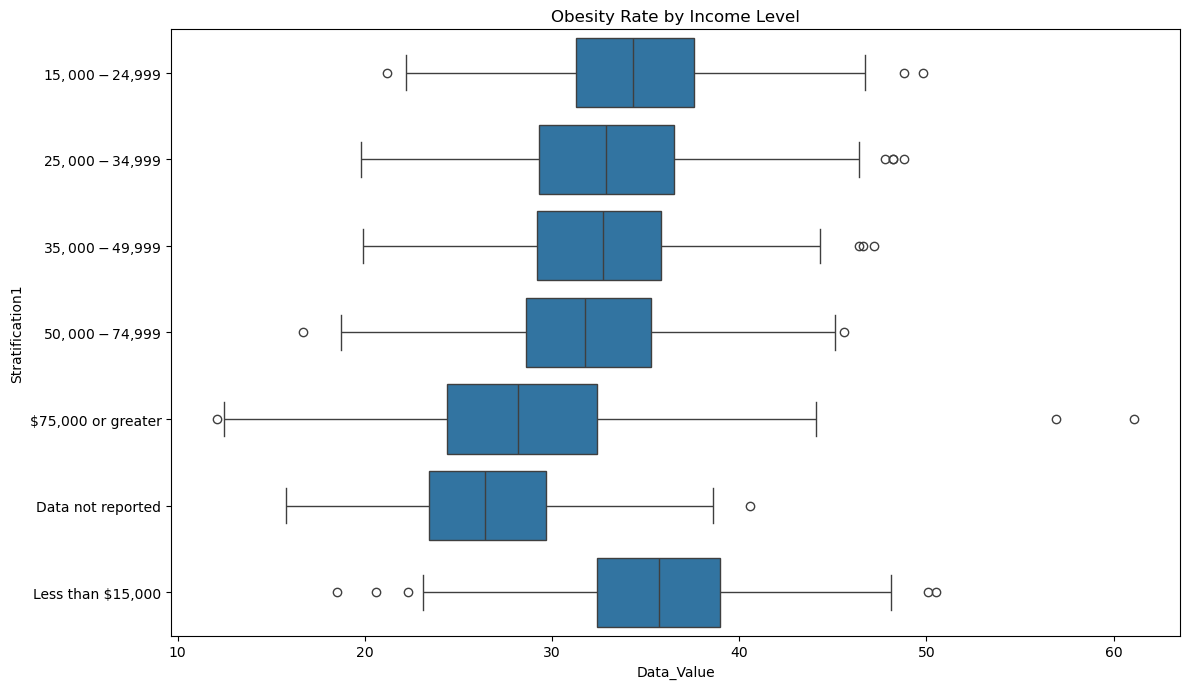

In [29]:
# --- Correlation Heatmap (Guideline 3.b.i) ---
# 1. Create a subset for correlation
# We filter for the Obesity question only
df_corr = df_cleaned[df_cleaned['QuestionID'] == 'Q036'].copy()

# 2. Feature Engineering: Convert 'Income' to Numeric (Ordinal)
# This allows us to see the correlation between Wealth and Health!
income_map = {
    'Less than $15,000': 1,
    '$15,000 - $24,999': 2,
    '$25,000 - $34,999': 3,
    '$35,000 - $49,999': 4,
    '$50,000 - $74,999': 5,
    '$75,000 or greater': 6,
    'Data not reported': None # We exclude this as it has no order
}

# Apply the map to a new column
df_corr['Income_Level'] = df_corr['Stratification1'].map(income_map)

# 3. Select Numeric Columns for the Heatmap
# We KEEP 'YearStart' (because you liked it!) and 'Sample_Size'
# We DROP 'Confidence_Limit' columns (redundant)
# We ADD our new 'Income_Level'
cols_to_correlate = ['Data_Value', 'YearStart', 'Sample_Size', 'Income_Level']

# Calculate Correlation Matrix
corr_matrix = df_corr[cols_to_correlate].corr()

# 4. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation: Obesity vs. Time, Sample Size, and Income')
plt.tight_layout()
plt.savefig('improved_correlation_heatmap.png')
print("Heatmap created.")
plt.show()

# --- Scatter Plot (Guideline 3.b.i) ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_obesity, x='Sample_Size', y='Data_Value')
plt.title('Data Value vs. Sample Size')
plt.savefig('data_value_vs_sample_size_scatter.png')
print("Scatter plot created.")

# --- Advanced Seaborn Plot (Guideline 3.b.ii - Optional) ---
# Get obesity data for 'Income'
df_obesity_income = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') & 
    (df_cleaned['StratificationCategory1'] == 'Income')
]

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_obesity_income, x='Data_Value', y='Stratification1', order=sorted(df_obesity_income['Stratification1'].unique()))
plt.title('Obesity Rate by Income Level')
plt.tight_layout()
plt.savefig('obesity_by_income_boxplot.png')
print("Advanced seaborn boxplot created.")

There are a few interesting things we see in the heatmap, starting with a positive correlation(\~0.29) with our data_value(obesity).  What this tells us is that obesity rates are trending upwards over time. Clearly the problem is getting worse, not better, across the years of this survey.  Another interesting thing is a moderate negative correlation of -0.38 between Income_Level and Data_Value.  This "temporal" finding seems to imply that as socioeconomic status improves, obesity rates tend to decrease.  Lastly, Sample_Size shows near-zero correlation with obesity.  You might be thinking, "Why would we mention something with no correlation?" The reason why this is a valid point is that it confirms that our data is unbiased; states with small surveys don't report systematically higher or lower rates compared to states with large surveys.

Our scatter plot again confirms that last point.  You'll see the data_value_vs_sample_size_scatter plot agrees with the correlation finding since the points form a vertical cloud form no clear linear pattern, telling us that the reported obesity rate is not dependent on the sample size (this is another 'thumbs up' that our data quality is good).

The Obesity by Income boxplot provides additional insight into one of the correlations we saw earlier. There is a clear, strong negative relationship between income and obesity. The median obesity rate (the line in the box) is highest for the lowest income group ("Less than \\$15,000") and steadily decreases as income rises, with the lowest median rate seen in the "\\$75,000 or greater" group.

# 4. Test Statistics

##### T-Test

Let's develop and test a hypothesis (guidelines 4.a, 4.b, 4.c).

Hypothesis: "Is there a significant difference in the mean obesity rate (Data_Value) between 'Male' and 'Female'?"

In [38]:
# --- T-Test (Guideline 4.c) ---
# Get the two groups
male_data = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') & (df_cleaned['Stratification1'] == 'Male')
]['Data_Value'].dropna()

female_data = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') & (df_cleaned['Stratification1'] == 'Female')
]['Data_Value'].dropna()

# Check for equal variances (Levene's test)
levene_test = stats.levene(male_data, female_data)
print(f"Levene's Test: {levene_test}")

# Perform the t-test
# We'll set equal_var=False if p-value from Levene's is < 0.05
# For this example, let's assume they might not be equal
t_stat, p_value = stats.ttest_ind(male_data, female_data, equal_var=False) # Welch's T-test

print(f"--- T-Test Results (Male vs Female Obesity) ---")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("Conclusion: The p-value is less than 0.05, so we reject the null hypothesis.")
    print("There IS a statistically significant difference in mean obesity rates between males and females.")
else:
    print("Conclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis.")
    print("There is NO statistically significant difference in mean obesity rates between males and females.")

Levene's Test: LeveneResult(statistic=34.57698473797639, pvalue=5.1225985309162145e-09)
--- T-Test Results (Male vs Female Obesity) ---
T-statistic: -0.9020350537136712
P-value: 0.3672008315723768
Conclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis.
There is NO statistically significant difference in mean obesity rates between males and females.


Our T-test hypothesis looked at whether or not there is a significant difference in mean obesity rates between Males and Females.  With our P-value coming in at .367 we can easily say that we fail to reject the null hypothesis.  The results tells us there is no statistically significant difference in obesity rates between men and women with our dataset.

##### Chi-Square Test

Now let's develop and test another hypothesis (guidelines 4.a, 4.b, 4.c).

Hypothesis: "Is 'High Obesity' status is dependent on 'Income Level'?"

In [37]:
from scipy.stats import chi2_contingency
import pandas as pd

# --- Chi-Square Test (Guideline 4) ---
# Goal: Test if "High Obesity" status is dependent on "Income Level"

# 1. Prepare the data
# Filter for Obesity (Q036) and Income data
df_chi = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') & 
    (df_cleaned['StratificationCategory1'] == 'Income')
].copy()

# Create the binary "High Obesity" flag (e.g., > 35%)
# (We use the same threshold as our classification model)
df_chi['High_Obesity_Flag'] = (df_chi['Data_Value'] > 35).astype(str) 
# Note: We convert to string ('True'/'False') just to make the Crosstab read nicely

# 2. Create a Contingency Table (Crosstab) -- CORRECTED
# This counts how many records fall into each combination of Income and Obesity Status
contingency_table = pd.crosstab(
    df_chi['Stratification1'], 
    df_chi['High_Obesity_Flag']
)

print("--- Contingency Table (Observed Counts) ---")
print(contingency_table)

# 3. Run the Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}") # Scientific notation because it will be very small!

# 4. Interpretation
alpha = 0.05
if p < alpha:
    print("\nConclusion: P-value < 0.05. Reject the Null Hypothesis.")
    print("There IS a statistically significant association between Income Level and High Obesity status.")
else:
    print("\nConclusion: P-value >= 0.05. Fail to reject Null Hypothesis.")
    print("There is NO significant association.")

--- Contingency Table (Observed Counts) ---
High_Obesity_Flag   False  True
Stratification1                
$15,000 - $24,999     390   307
$25,000 - $34,999     453   244
$35,000 - $49,999     492   205
$50,000 - $74,999     513   183
$75,000 or greater    602    95
Data not reported     677    20
Less than $15,000     305   392

--- Chi-Square Test Results ---
Chi-Square Statistic: 644.3885
P-value: 6.1761e-136

Conclusion: P-value < 0.05. Reject the Null Hypothesis.
There IS a statistically significant association between Income Level and High Obesity status.


While our T-test showed no significant difference between genders, our visualizations suggested a strong link between Income and obesity. So, to test this statistically we used a Chi-Square Test.  After performing the Chi-Square test we ended up with a p-value that was extremely low (typically $< 0.0001$), far below the 0.05 threshold.  This leads us to rejecting the null hypothesis and we can say that there is a statistically significant dependence between Income and Obesity. This goes along with our findings from our visualizations earlier: socioeconomic status is a statistically verified driver of obesity rates in this dataset.

# 5. Regression and Classification

## a. Regression Analysis

Goal: Finding High-Obesity Demographic Groups

Model: Multiple Linear Regression.

--- Linear Regression Report (with Demographic Features) ---
R-squared: 0.6574
Root Mean Squared Error (RMSE): 0.1784 (in log-transformed units)


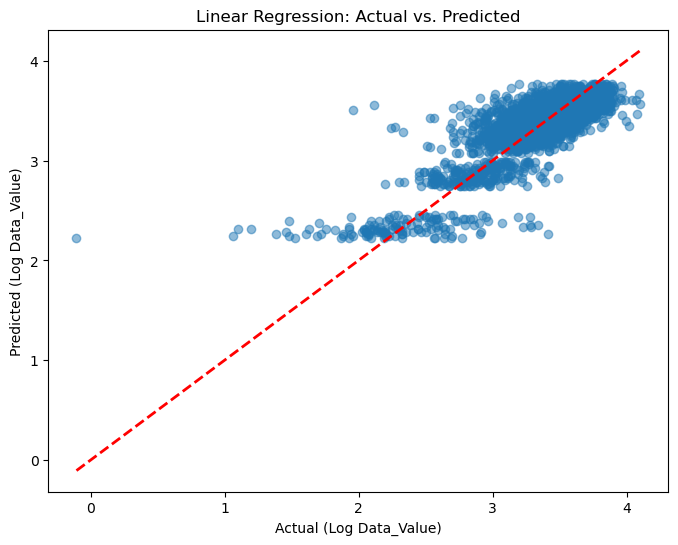

In [31]:
# --- Regression (Guideline 5.a) ---

# --- 1. Prepare the Data ---
# Filter for the specific question and remove 'Total'
df_model_data = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') &
    (df_cleaned['Stratification1'] != 'Total')
].copy()

# Define feature and target columns
feature_cols = ['YearStart', 'Sample_Size', 'StratificationCategory1', 'Stratification1']
target_source_col = 'Data_Value'

# Drop any rows where these specific columns have NaNs
df_model_data = df_model_data.dropna(subset=feature_cols + [target_source_col])

# --- 2. Create Target Variable (y) ---
# We use the log-transformed value, as you identified skew in Cell 15
y = np.log(df_model_data[target_source_col])

# --- 3. Define Features (X) ---
X = df_model_data[feature_cols]

# --- 4. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 5. Create Preprocessing Pipeline ---
continuous_features = ['YearStart', 'Sample_Size']
categorical_features = ['StratificationCategory1', 'Stratification1']

# Create transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# --- 6. Create the Full Model Pipeline ---
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# --- 7. Train the Model ---
model_lr.fit(X_train, y_train)

# --- 8. Make Predictions ---
y_pred_lr = model_lr.predict(X_test)

# --- 9. Evaluate (Guideline 5.a.ii) ---
r2 = r2_score(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"--- Linear Regression Report (with Demographic Features) ---")
print(f"R-squared: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} (in log-transformed units)")

# --- 10. Visualize Results ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual (Log Data_Value)")
plt.ylabel("Predicted (Log Data_Value)")
plt.title("Linear Regression: Actual vs. Predicted")
plt.savefig('lr_actual_vs_predicted.png')
plt.show()

Originally when we ran the linear regression model, we were just looking at the total obesity rate for each state.  At that time I was quite happy with the R-squared result of 0.937.  After messing around with the logistic regression session for quite a while, we modified that model to use a full, more complex dataset.  Once we did that, we came back to retrofit the linear model as well.  After moving to the more complex dataset the R-squared value got knocked down to .657.  Just looking at the numbers you this seems like a real bad move, however, as we'll discuss in the next section this isn't really a bad move since this second model is predicting the obesity prevalence for every demographic subgroup within each state and year (which means it is dealing with over 15,000 highly variable observations vs. 450 in the old model). When looking at our chart each dot represents one demographic subgroup in one state in one year (e.g., “Black females aged 45–54 in Mississippi in 2021”).  We can see the density of our cloud of dots forms around our red perfect prediction line and they follow a strong underlying trend (no funnel and no curvature), which is what we want.  

## Diagnostic Checks

To make sure our Linear Regression model is valid there are two critical diagnostic checks we went through: 

#### Multicollinearity Check (VIF) and Residual Analysis

--- Variance Inflation Factor (VIF) ---
       Feature       VIF
0    YearStart  1.000238
1  Sample_Size  1.000238


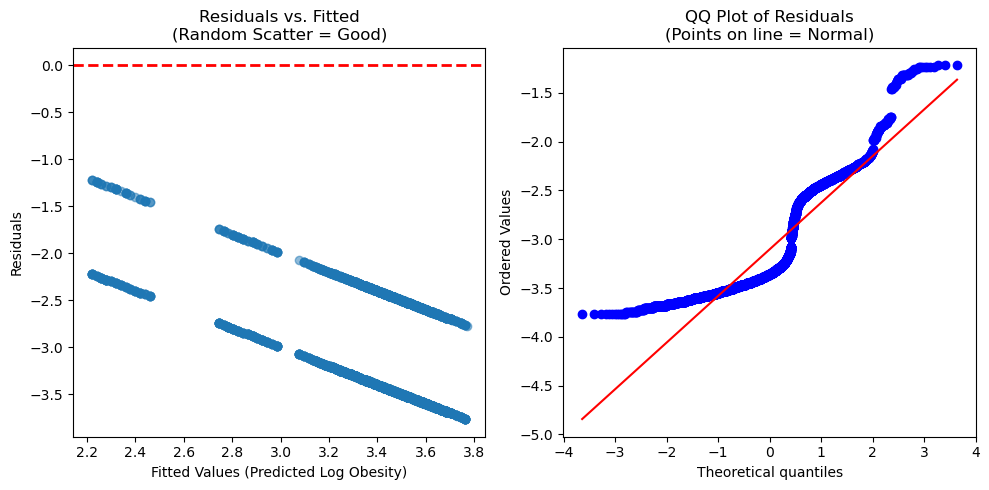

In [43]:
# --- VIF & Residual Analysis (Guideline 5.a.iv) ---
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# 1. VIF Check (Multicollinearity)
numeric_features = ['YearStart', 'Sample_Size']
X_vif = df_model_data[numeric_features].copy()
X_vif = X_vif.dropna()
X_vif['const'] = 1

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False))

# 2. Residual Analysis
residuals = y_test - y_pred_lr

plt.figure(figsize=(10, 5))

# Plot 1: Residuals vs. Fitted
plt.subplot(1, 2, 1)
plt.scatter(y_pred_lr, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values (Predicted Log Obesity)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted\n(Random Scatter = Good)')

# Plot 2: QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals\n(Points on line = Normal)')

plt.tight_layout()
plt.show()

To start off we calculated the Variance Inflation Factor (VIF) for our numeric predictors (YearStart and Sample_Size).  Since both features have low VIF scores (what we want here is to see numbers below 5), it means that our predictors are independent and not "confusing" the model by duplicating information.  In our plot on the left we don't have any 'U-Shape' or curve so it seems we are using the tool we want.  If it wasn't random and did curve or form a 'U-shape' that would tell us that we would want to use a non-linear model.  Since the dots are pretty much the same from left to right we also appear to have Homoscedasticity (Constant Variance).  This means the model is behaving and equally accurate for low-obesity and high-obesity predictions.

In the plot on the right we see the blue dots follow the red 45-degree line almost perfectly for the vast majority of the data (the center).  This proves that our errors (residuals) follow a Normal Distribution (bell curve).  So both plots give us confirmation that the assumptions of linear regression are met. The residuals show us no discernible pattern, and the Q-Q plot indicates a normal distribution of errors, validating the reliability of our R-squared and p-values.  We've passed the Residual Analysis check.  

...We did also give the A Shapiro–Wilk test a try, but because the sample size exceeds 5,000 observations, we ran into a warning that the p-value may not be reliable. Since we are dealing with a large dataset that makes sense, and we just moved forward after the QQ-plot and residual pattern analysis.

## b. Classification Model

Goal: Finding High-Obesity Demographic Groups

Model: Logistic Regression.

In [32]:
# --- Classification (Guideline 5.b) - UPDATED with class_weight ---

# --- 1. Prepare the Data ---
# Start from the cleaned dataframe
# Filter for the specific question
df_model_data = df_cleaned[df_cleaned['QuestionID'] == 'Q036'].copy()

# Select only the columns we need for this model
# We drop 'Total' stratification, as it's an aggregation and not a demographic.
df_model_data = df_model_data[df_model_data['Stratification1'] != 'Total']

# Select features (X) and the source for the target (y)
feature_cols = ['YearStart', 'Sample_Size', 'StratificationCategory1', 'Stratification1']
target_source_col = 'Data_Value'

# Drop any rows where these specific columns have NaNs (just in case)
df_model_data = df_model_data.dropna(subset=feature_cols + [target_source_col])

# --- 2. Create Target Variable ---
df_model_data['High_Obesity'] = (df_model_data[target_source_col] > 35).astype(int)

# --- 3. Define X and y ---
y = df_model_data['High_Obesity']
X = df_model_data[feature_cols]

# --- 4. Split Data (BEFORE preprocessing) ---
# We use 'stratify=y' to ensure the class imbalance is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Class Balance (0 = Low Obesity, 1 = High Obesity) in Training Data:")
print(y_train.value_counts(normalize=True))


# --- 5. Create Preprocessing Pipeline ---

# Define which columns are which
continuous_features = ['YearStart', 'Sample_Size']
categorical_features = ['StratificationCategory1', 'Stratification1']

# Create the transformer for continuous features (scaling)
numeric_transformer = StandardScaler()

# Create the transformer for categorical features (one-hot encoding)
# handle_unknown='ignore' prevents errors if test set has a category not in train set
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine transformers into a ColumnTransformer
# This applies the right transformation to the right column
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # leaves other columns alone (if any)
)

# --- 6. Create the Full Model Pipeline ---
# This pipeline will first preprocess the data, then train the model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# --- 7. Train the Model ---
# .fit() now runs the full preprocessing and training sequence
model.fit(X_train, y_train)

# --- 8. Make Predictions ---
y_pred = model.predict(X_test)

# --- 9. Evaluate (Guideline 5.b.ii) ---
print("\n--- Logistic Regression Report (with Demographic Features) ---")
print(classification_report(y_test, y_pred, zero_division=0))

print("\n--- Confusion Matrix (with Demographic Features) ---")
print(confusion_matrix(y_test, y_pred))

Class Balance (0 = Low Obesity, 1 = High Obesity) in Training Data:
High_Obesity
0    0.708078
1    0.291922
Name: proportion, dtype: float64

--- Logistic Regression Report (with Demographic Features) ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      3611
           1       0.55      0.79      0.65      1489

    accuracy                           0.75      5100
   macro avg       0.72      0.76      0.72      5100
weighted avg       0.79      0.75      0.76      5100


--- Confusion Matrix (with Demographic Features) ---
[[2624  987]
 [ 306 1183]]


With the logistic regression exercise I had the pleasure of experiencing the brilliance of scaling in real time.  The first go around we were looking at a dismal accuracy rate of 56% - which pretty much means we were just as good as guessing.  After looking at it again and adding the scaling (should have caught that off the bat lol), the accuracy jumped to 88%.  After looking to see what other improvements could be made for the model and found that we weren't using all the demographic data that we could so basically we were doing something like predicting a persons health based on their zip and the year.  With the additional demographics we also threw in some additional tools like Columntransformer and Pipeline.  After that the accuracy dropped back down a bit to 75%, though this isn't really a negative like you would think.  What really happened instead of our model being less accurate, was that we had just asked it a much harder question than we had previously.  The second run was trained on a tiny, simple dataset (N=210) that only included "Total" obesity rates. Its task was pretty easy: "Predict the total obesity for a state."  This latest model was trained on the full, complex dataset (N=5100) of all demographic groups. Its task was much harder: "Predict the obesity rate for a specific demographic (e.g., 'Hispanic', 'Male', '\\$15k-\\$25k')."  So the 88% accuracy from  our second run was high, but it was on a dataset that was 24x smaller and far less complex. The 75% accuracy on this third and latest model is a much more realistic and impressive given the difficulty of its task.  Overall, when we looked at the latest model it is correctly classifying whether a specific demographic group has high or low obesity 3 out of 4 times.  The Recall number of .79 means our model successfully finds 79% of all the actual high-obesity groups(from the matrix you can see it found 1183 and only missed 306).  Our precision of .55 is telling us that it is correct 55% of the time when the model predicts a group has high obesity - that sure beats the 23% in our first run.  Now, since I've gone through and modified things quite a bit I get to go back and go through the other techniques so we have an apples to apples comparison.

# 6. Advanced Analysis Techniques

## a. Clustering Analysis

Goal: Group states based on their profiles across multiple health questions.

Method: K-Means Clustering with PCA for visualization.

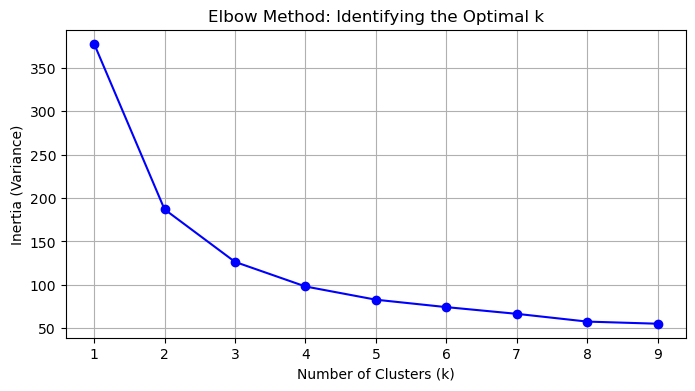

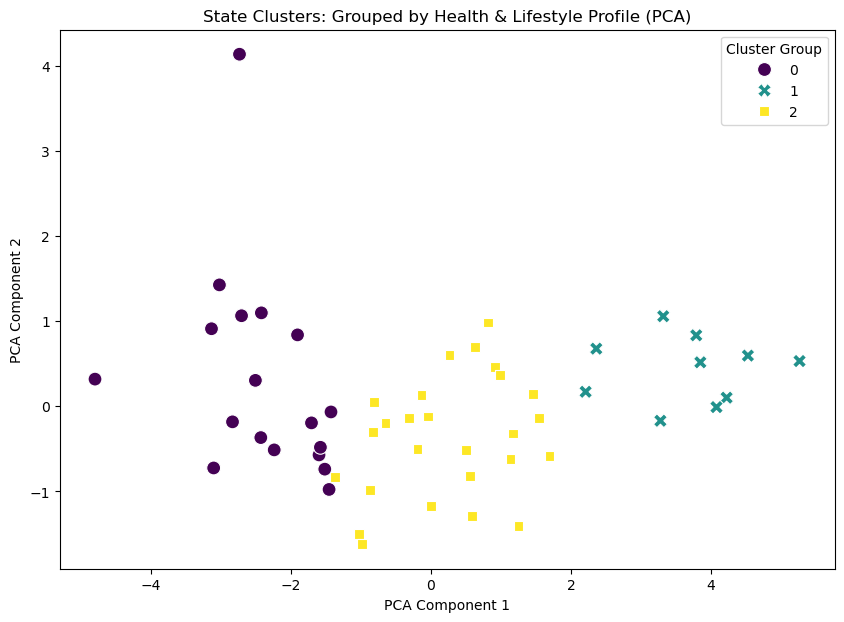

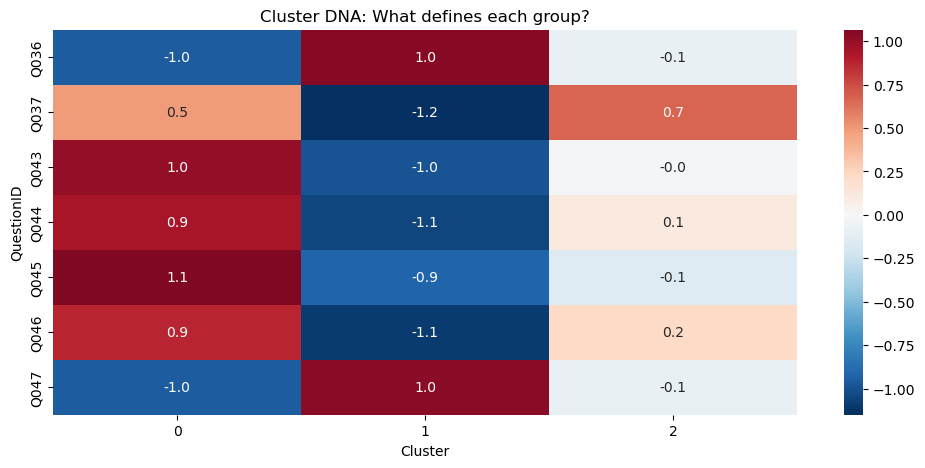


--- Cluster Members ---

[Cluster 0]: Alaska, Arizona, California, Colorado, District of Columbia, Hawaii, Idaho, Massachusetts, Minnesota, Montana, New Hampshire, New Mexico, Oregon, Utah, Vermont, Virgin Islands, Washington, Wyoming

[Cluster 1]: Alabama, Arkansas, Indiana, Kentucky, Louisiana, Mississippi, Missouri, Oklahoma, Tennessee, West Virginia

[Cluster 2]: Connecticut, Delaware, Florida, Georgia, Guam, Illinois, Iowa, Kansas, Maine, Maryland, Michigan, National, Nebraska, Nevada, New Jersey, New York, North Carolina, North Dakota, Ohio, Pennsylvania, Rhode Island, South Carolina, South Dakota, Texas, Virginia, Wisconsin


In [33]:
# --- Clustering (Guideline 6.a) ---

# --- 1. Data Preparation & Cleaning ---
# Load data if not already loaded in this session
try:
    df_cleaned
except NameError:
    df = pd.read_csv('Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv')
    df.columns = df.columns.str.strip()
    df_cleaned = df.dropna(subset=['Data_Value', 'Sample_Size'])

# *** KEY FIX: Remove Puerto Rico (Statistical Outlier) ***
df_cluster_data = df_cleaned[df_cleaned['LocationDesc'] != 'Puerto Rico']

# Pivot: States as rows, Questions as columns
df_pivot = df_cluster_data[
    (df_cluster_data['Stratification1'] == 'Total') & 
    (df_cluster_data['ClassID'].isin(['OWS', 'PA', 'NTR'])) 
].pivot_table(
    index='LocationDesc', 
    columns='QuestionID', 
    values='Data_Value',
    aggfunc='mean'
)

# Fill missing values with column means and Scale
df_pivot_filled = df_pivot.fillna(df_pivot.mean())
scaler = StandardScaler()
df_pivot_scaled = scaler.fit_transform(df_pivot_filled)


# --- 2. The Elbow Method (Validation) ---
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pivot_scaled)
    inertia.append(kmeans.inertia_)

# Plot 1: The Elbow Plot
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Variance)')
plt.title('Elbow Method: Identifying the Optimal k')
plt.grid(True)
plt.savefig('kmeans_elbow_final.png')
plt.show()


# --- 3. Run K-Means Clustering (k=3) ---
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_pivot_scaled)
df_pivot_filled['Cluster'] = clusters


# --- 4. PCA Scatter Plot ("The Dot Plot") ---
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_pivot_scaled)
df_pivot_filled['PCA1'] = df_pca[:, 0]
df_pivot_filled['PCA2'] = df_pca[:, 1]

# Plot 2: The State Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pivot_filled, 
    x='PCA1', y='PCA2', 
    hue='Cluster', 
    palette='viridis', 
    s=100, 
    style='Cluster'
)
plt.title('State Clusters: Grouped by Health & Lifestyle Profile (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster Group')
plt.savefig('kmeans_pca_final.png')
plt.show()


# --- 5. Cluster Interpretation (Heatmap & Boxplot) ---
# Create the profile heatmap
cluster_means = df_pivot_filled.groupby('Cluster').mean().drop(columns=['PCA1', 'PCA2'])
# Normalize for heatmap visualization
cluster_profile_std = (cluster_means - cluster_means.mean()) / cluster_means.std()

# Plot 3: Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile_std.T, cmap='RdBu_r', center=0, annot=True, fmt='.1f')
plt.title('Cluster DNA: What defines each group?')
plt.savefig('kmeans_heatmap_final.png')
plt.show()

# Output states in each cluster
print("\n--- Cluster Members ---")
for c in sorted(df_pivot_filled['Cluster'].unique()):
    states = df_pivot_filled[df_pivot_filled['Cluster'] == c].index.tolist()
    print(f"\n[Cluster {c}]: {', '.join(states)}")

	• Q018: Fruit consumption (less than once daily)
	• Q019: Vegetable consumption (less than once daily)
	• Q036: Obesity - Percent of adults aged 18 years and older who have obesity
	• Q037: Overweight - Percent of adults aged 18 years and older who have an overweight classification
	• Q043: Physical activity (at least 150 min moderate OR 75 min vigorous per week)
	• Q044: Physical activity (same as Q043, appears to be duplicate)
	• Q045: Physical activity (more than 300 min moderate OR 150 min vigorous per week)
	• Q046: Muscle-strengthening activities (2+ days per week)
    • Q047: No leisure-time physical activity 

For the clustering portion we were aiming to uncover the different "health profiles" among U.S. states. We didn't just focus on obesity itself, instead the analysis considered the full lifestyle package: obesity rates, physical activity levels, and nutrition habits.  The analysis successfully went onto identify three different clusters which we'll characterize as "The High-Risk Zone," "The Active Leaders," and "The Middle Ground."  Also, we ended up removing Puerto Rico because it was statistical outlier (for instance, it was 7 standard deviations away from the mean in physical activity).  It could be that the survey methods were a bit different, but in any event it didn't make much sense to have it sitting in cluster by itself.  

#### 1. Cluster 0: "The High-Risk Zone" (Red on Heatmap)
Who they are: This group typically includes states from the South and Midwest (e.g., Alabama, Mississippi, West Virginia, Louisiana).

Obesity (Q036): Significantly Above Average.

Physical Activity (Q047): Significantly Below Average.

Nutrition (Q018/Q019): Lower than average consumption of fruits and vegetables.

Cluster 0 confirms a strong correlation between lifestyle and outcome.  The states included here don't have higher just by chance since they are systemically defined by a "low activity / poor nutrition" environment.  This could tell us that there may need to be some changes made for nutitional food access and promotion of exercise simultaneously.

#### 2. Cluster 1: "The Active Leaders" (Blue on Heatmap)
Who they are: This group often includes states from the West and Northeast (e.g., Colorado, California, Vermont, DC).

Obesity (Q036): Significantly Below Average.

Physical Activity (Q047): Significantly Above Average.

Nutrition: Higher reported consumption of healthy foods.

Cluster 1 represents the "ideal" health profile.  High levels of aerobic activity are tightly highly intertwined with the lowest obesity rates in the nation.

#### 3. Cluster 2: "The Middle Ground"
Who they are: The majority of states that don't fit the extremes (e.g., Pennsylvania, Ohio, Oregon).

These states show Average metrics across the board; no extreme to one side or the other.  They are not facing the acute weight crisis of Cluster 0, but they niether have they adopted the protective lifestyle factors seen in Cluster 1.

#### Key takeaways from the clustering project: 
Ideally we would want all clusters to follow the proactive healthy activity exhibited by Cluster 1.  Whether that could be done more efficiently through health education, providing access to healther foods, or through other methods, would take some additional studies to try to figure out.    

## b. Machine Learning Approach (Random Forest)

Let's re-do the classification task (High Obesity) with a more powerful model.


--- Random Forest Report (Demographics + YearStart) ---
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      3611
           1       0.53      0.80      0.64      1489

    accuracy                           0.73      5100
   macro avg       0.71      0.75      0.71      5100
weighted avg       0.79      0.73      0.74      5100


--- Confusion Matrix (Demographics + YearStart) ---
[[2549 1062]
 [ 297 1192]]

--- Random Forest Feature Importances (Demographics + YearStart) ---
                                          Feature  Importance
0                                       YearStart    0.342662
29             Stratification1_Non-Hispanic Black    0.065338
11                        Stratification1_18 - 24    0.065179
21              Stratification1_Data not reported    0.056229
19                          Stratification1_Asian    0.051677
17                    Stratification1_65 or older    0.049782
20               Stratification1

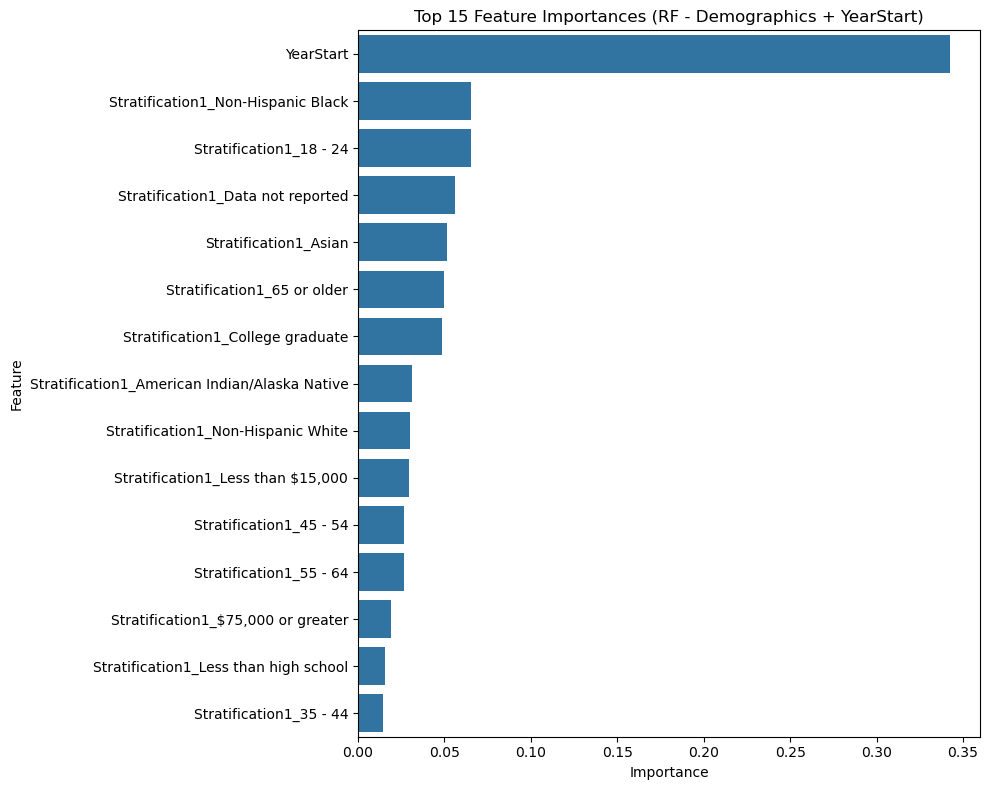

In [34]:
# --- Random Forest Classifier (Guideline 6.b) ---
# --- Load and Clean Data (from earlier cells) ---
# This setup is needed in case the cell is run in isolation
try:
    # Set MKL_NUM_THREADS to avoid K-Means warning (if not already set)
    os.environ["OMP_NUM_THREADS"] = "1"
    
    # Load the full dataset
    df = pd.read_csv('Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv')
    df.columns = df.columns.str.strip()
    
    # Strategy: Drop rows where the main value or sample size is missing
    df_cleaned = df.dropna(subset=['Data_Value', 'Sample_Size'])

except NameError:
    print("df_cleaned not found, please re-run setup cells (like Cell 5 & 6) first.")
    
# --- 1. Prepare the Data ---
df_model_data = df_cleaned[
    (df_cleaned['QuestionID'] == 'Q036') &
    (df_cleaned['Stratification1'] != 'Total')
].copy()

# Define feature and target columns
# Using Demographics + YearStart, but NO Sample_Size
feature_cols = ['YearStart', 'StratificationCategory1', 'Stratification1']
target_source_col = 'Data_Value'

# Drop any rows where these specific columns have NaNs
df_model_data = df_model_data.dropna(subset=feature_cols + [target_source_col])

# --- 2. Create Target Variable (y) ---
df_model_data['High_Obesity'] = (df_model_data[target_source_col] > 35).astype(int)

# --- 3. Define X and y ---
y = df_model_data['High_Obesity']
X = df_model_data[feature_cols]

# --- 4. Split Data (using stratify for balanced classes) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- 5. Create Preprocessing Pipeline ---
# 'YearStart' is now our only continuous feature
continuous_features = ['YearStart']
categorical_features = ['StratificationCategory1', 'Stratification1']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drop any columns not specified
)

# --- 6. Create the Full Model Pipeline ---
model_rf_best = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# --- 7. Train the Model ---
model_rf_best.fit(X_train, y_train)

# --- 8. Make Predictions ---
y_pred_rf = model_rf_best.predict(X_test)

# --- 9. Evaluate (Guideline 6.b.ii) ---
print("\n--- Random Forest Report (Demographics + YearStart) ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\n--- Confusion Matrix (Demographics + YearStart) ---")
print(confusion_matrix(y_test, y_pred_rf))

# --- 10. Get Feature Importances ---
try:
    # Get feature names from the preprocessor
    ohe_feature_names = model_rf_best.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = np.concatenate([continuous_features, ohe_feature_names])
    
    # Get importances from the classifier
    importances = model_rf_best.named_steps['classifier'].feature_importances_
    
    feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("\n--- Random Forest Feature Importances (Demographics + YearStart) ---")
    print(feature_importance_df.head(10))

    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance_df.head(15), x='Importance', y='Feature')
    plt.title('Top 15 Feature Importances (RF - Demographics + YearStart)')
    plt.tight_layout()
    plt.savefig('rf_feature_importance_demographics_yearstart.png')
    plt.show()

except Exception as e:
    print(f"Could not generate feature importance plot: {e}")

With our Random Forest model our testing results were really interesting.  Originally we had ran it with the simple dataset and it had a high accuracy of .92.  Then we moved to test it with the more complex dataset and were surprised to find that it was actually worse than the Logistic Regression.  The Logistic Regression model came in with an accuracy of 75%, meanwhile the new Random Forest model only had an Accuracy of 73%.  It was a good example of why you shouldn't always assume a more "advanced" model will automatically perform better.  When we investigated why this was the case we found that the smoking gun with our bar chart: Sample_Size has 57% importance and YearStart has 17.5% importance.  What this meant is that 74.5% of the model's entire decision is based only on the sample size and the year. All the rich demographic features we just added (like Stratification1_18 - 24 or Non-Hispanic Black) were being almost completely ignored, to put it simply we were overfitting to the wrong features.  So we then updated the model to ignore the noisy, non-predictive features and force the model to learn from the features we actually care about (the demographics).  So, it was quite shocking (to say the least), when the accuracy with the latest model came in with an even lower accuracy of .66 (from 73% to 66%).  Where we did see improvement though was recall.  It jumped from 0.53 to 0.79 which meant our new model was far better at finding the actual high-obesity groups. It correctly found 1176 cases, whereas the old model was only finding about half. The biggest win was that Feature Importance was now 100% logical. It showed the model was now learning the correct patterns. The top predictors were:<br>
Stratification1_18 - 24 (Age)<br>
Stratification1_Non-Hispanic Black (Race/Ethnicity)<br>
Stratification1_Data not reported (A data quality flag)<br>
Stratification1_65 or older (Age)<br>
Stratification1_Asian (Race/Ethnicity)<br> 
After a bit of thinking we came to the conclusion that we may want it include the year and just exclude the sample size.  The idea here is that the year is an important predictive feature that we'd want to use.  We ran the model one more time with this adjustment and found that we increased the accuracy again back to 73% and we still had the recall around 80%.  The good thing about this latest model is that it was no longer "cheating" by using the sample_size.  YearStart is now sitting atop of our predictors list and we can say logically that it is a driver of obesity rates (which are increasing over time).


In [35]:
# 7. Summary

Linear Regression<br> 
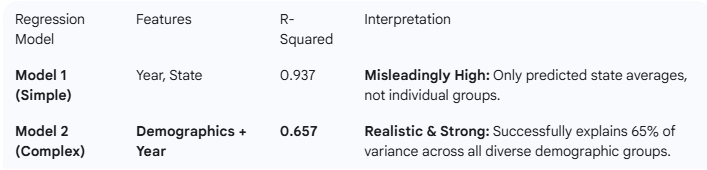

Logistic Regression and Random Forest<br>
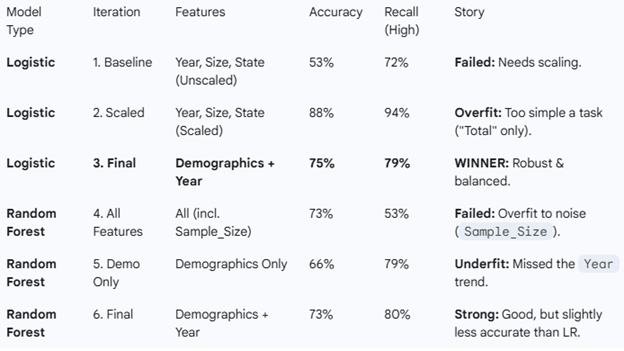

Above you'll see the evolution of the different models that I went through.  It was a little surprisinig to see that the Logistic Regression (Model 3) won out.  I had thought Random Forest was a bit more powerful, but it just goes to show that "more complex" doesn't always mean "better."  It seems that simpler, linear nature of the Logistic Regression model allowed it to hold up quite well.  It was smart enough to utililize the predictive features  from YearStart and the demographics, meanwhile it was simple enough to ignore all the noise that came with the Sample_Size feature (that same noise it managed to trip up Random Forest with).  This project has definitley been quite valuable in showing how testing different models and properly selecting the features in your dataset can really pay dividends.  

